# Token Graph: Clonotypes × Tokens

Builds a **bipartite graph** from GILGFVFTL-specific TRB CDR3 clonotypes where:

* **Clonotype nodes** — one per unique CDR3 sequence.
* **Token nodes** — one per unique annotated 3-mer.

An edge connects a clonotype to every token appearing in its CDR3.

The notebook shows the full graph (one giant CC) **before** applying the RS filter,
highlighting which nodes are retained versus removed, then shows the RS-filtered cluster.

In [1]:
# Import dependencies and configure project-local imports.
import sys
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.basic.token_tables import (
    filter_token_table,
    tokenize_clonotypes,
 )
from mir.graph.token_graph import build_token_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and build token tables

In [2]:
# Load VDJdb subset, construct clonotypes, and build token tables.
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb_path = find_airr_benchmark_vdjdb_slim(benchmark_root)
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

mask = vdjdb["gene"].eq("TRB") & vdjdb["antigen.epitope"].eq("GILGFVFTL")
if "species" in vdjdb.columns:
    mask &= vdjdb["species"].eq("HomoSapiens")
if "mhc.a" in vdjdb.columns:
    mask &= vdjdb["mhc.a"].fillna("").str.contains("A*02", regex=False)

cdr3s = sorted(vdjdb.loc[mask, "cdr3"].dropna().astype(str).unique())
K = 3

clonotypes = [
    Clonotype(
        sequence_id=str(i),
        locus="TRB",
        v_gene="TRBV",
        j_gene="TRBJ",
        junction_aa=seq,
        duplicate_count=1,
    )
    for i, seq in enumerate(cdr3s)
]

table = tokenize_clonotypes(clonotypes, k=K)
rs_table = filter_token_table(table, kmer_pattern="RS")

rs_token_seqs = {k.seq.decode() for k in rs_table}

print(f"Loaded {len(clonotypes)} clonotypes from {vdjdb_path}")
print(f"Sequences      : {len(clonotypes)}  ({sum('RS' in s for s in cdr3s)} with RS)")
print(f"Total {K}-tokens : {len(table)}")
print(f"RS {K}-tokens    : {len(rs_table)}  {sorted(rs_token_seqs)}")

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 1374.88it/s]


Loaded 5236 clonotypes from /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb.slim.txt.gz
Sequences      : 5236  (680 with RS)
Total 3-tokens : 4148
RS 3-tokens    : 38  ['ARS', 'DRS', 'ERS', 'FRS', 'GRS', 'HRS', 'IRS', 'KRS', 'LRS', 'MRS', 'NRS', 'PRS', 'QRS', 'RRS', 'RSA', 'RSD', 'RSE', 'RSF', 'RSG', 'RSH', 'RSI', 'RSK', 'RSL', 'RSM', 'RSN', 'RSP', 'RSQ', 'RSR', 'RSS', 'RST', 'RSV', 'RSW', 'RSY', 'SRS', 'TRS', 'VRS', 'WRS', 'YRS']


## 2. Full graph summary

All CDR3s share common non-RS tokens (for example `CAS`, `ASS`), so the full
token graph forms a **single giant CC**. After RS filtering, non-RS clonotypes
become isolated singletons and non-RS tokens are removed from the graph.

In [3]:
# Build full and RS-filtered token graphs and summarize retained node counts.
g_full = build_token_graph(clonotypes, table)
g_rs = build_token_graph(clonotypes, rs_table)

full_cc = g_full.components().giant()
filt_cc = g_rs.components().giant()

# Sets of junction_aa in filtered CC (to label retained nodes in full CC)
retained_r = {v["name"] for v in filt_cc.vs if v["node_type"] == "rearrangement"}
retained_k = {v["name"] for v in filt_cc.vs if v["node_type"] == "kmer"}

n_full_r = sum(1 for v in full_cc.vs if v["node_type"] == "rearrangement")
n_full_k = sum(1 for v in full_cc.vs if v["node_type"] == "kmer")
n_nonrs_r = sum(1 for v in full_cc.vs if v["node_type"] == "rearrangement" and v["name"] not in retained_r)
n_nonrs_k = sum(1 for v in full_cc.vs if v["node_type"] == "kmer" and v["name"] not in retained_k)
n_rs_r = len(retained_r)
n_rs_k = len(retained_k)

print(f"Full CC : {full_cc.vcount()} nodes  ({n_full_r} clonotypes, {n_full_k} tokens)")
print(f"  -> removed by RS filter : {n_nonrs_r} clonotypes + {n_nonrs_k} tokens")
print(f"  -> retained by RS filter: {n_rs_r} clonotypes + {n_rs_k} tokens")
print(f"RS-filtered giant CC: {filt_cc.vcount()} nodes  ({n_rs_r} clonotypes, {n_rs_k} tokens)")

Full CC : 9384 nodes  (5236 clonotypes, 4148 tokens)
  -> removed by RS filter : 4556 clonotypes + 4110 tokens
  -> retained by RS filter: 680 clonotypes + 38 tokens
RS-filtered giant CC: 718 nodes  (680 clonotypes, 38 tokens)


## 3. Full force-directed layout with top-degree highlights

Colour meaning in the **full graph** (before filtering):

| Colour | Meaning |
|--------|---------|
| Red    | Non-RS token - removed by RS filtering |
| Salmon | Non-RS clonotype - isolated by RS filtering |
| Orange | RS token - retained |
| Blue   | RS clonotype - retained |

Only the **top 10 clonotypes** and **top 10 tokens** by degree are highlighted and labelled
to keep the plot readable.

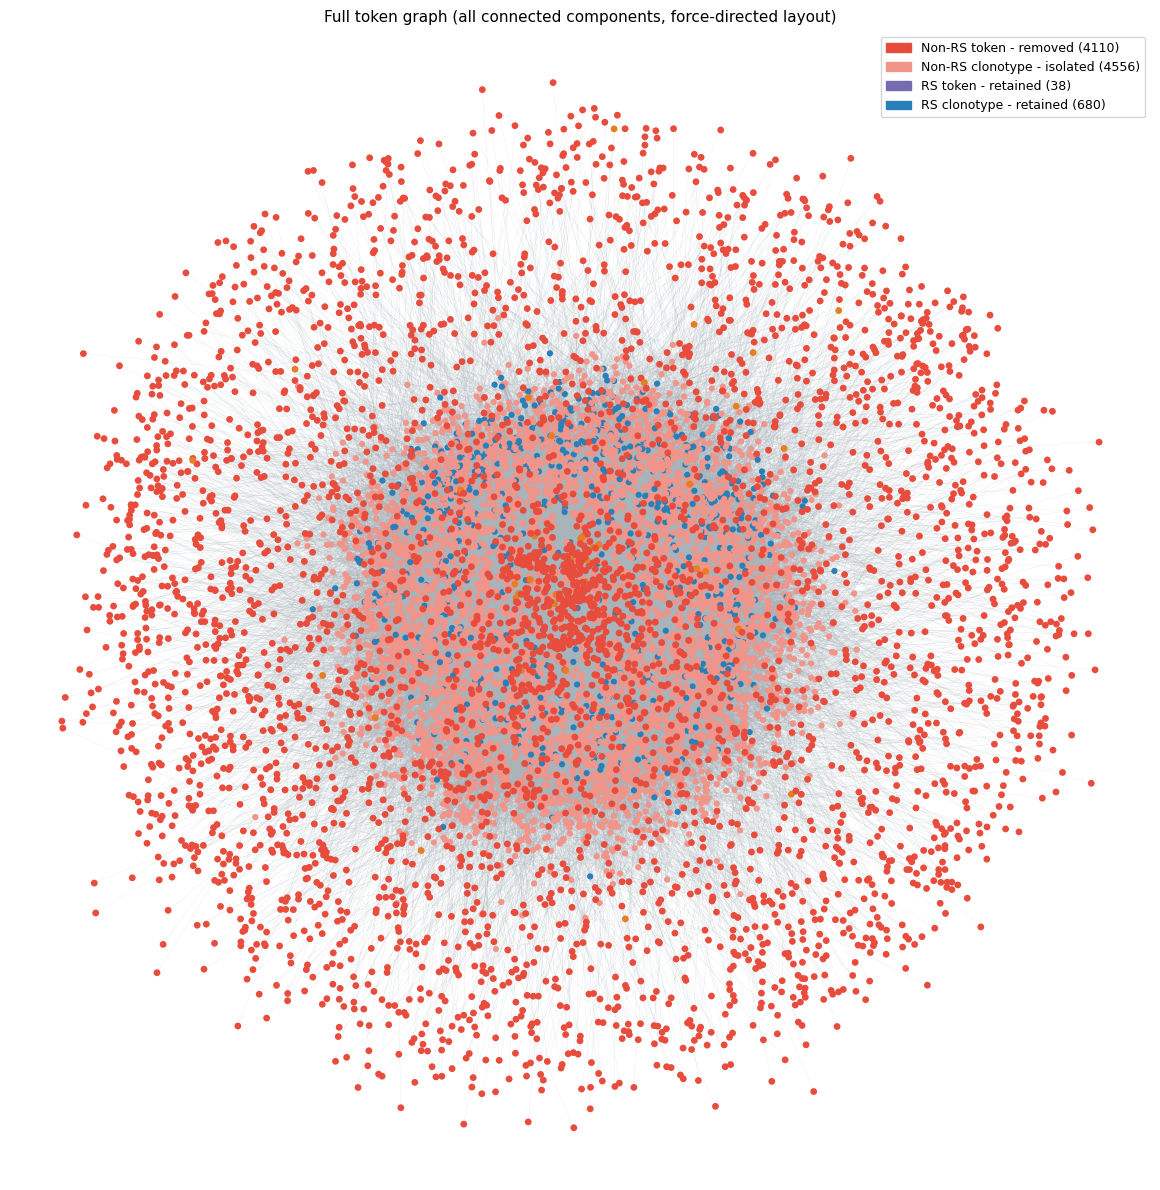

In [20]:
# Visualize all connected components of the full graph with a packed force-directed layout.
subg = g_full
degrees = subg.degree()

top_n = 10
clonotype_idx = [v.index for v in subg.vs if v["node_type"] == "rearrangement"]
token_idx = [v.index for v in subg.vs if v["node_type"] == "kmer"]

ordered_clonotypes = sorted(clonotype_idx, key=lambda i: (-degrees[i], subg.vs[i]["name"]))
ordered_tokens = sorted(token_idx, key=lambda i: (-degrees[i], subg.vs[i]["name"]))

top_clonotype_idx = set(ordered_clonotypes[:top_n])
top_token_idx = set(ordered_tokens[:top_n])
highlight_idx = top_clonotype_idx | top_token_idx

max_deg = max(1, max(degrees))

# Compute component-aware coordinates: FR inside each component, then pack components into a grid.
components = [list(comp) for comp in subg.components()]
component_blocks = []
for comp_vertices in components:
    if len(comp_vertices) == 1:
        coords_local = [(0.0, 0.0)]
        width = 1.0
        height = 1.0
    else:
        comp_sub = subg.subgraph(comp_vertices)
        local_layout = comp_sub.layout("fr").coords
        xs = [c[0] for c in local_layout]
        ys = [c[1] for c in local_layout]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        width = max(1.0, max_x - min_x)
        height = max(1.0, max_y - min_y)
        coords_local = [(c[0] - min_x, c[1] - min_y) for c in local_layout]

    component_blocks.append(
        {
            "vertices": comp_vertices,
            "coords": coords_local,
            "width": width,
            "height": height,
        }
    )

component_blocks.sort(key=lambda d: len(d["vertices"]), reverse=True)
max_w = max(block["width"] for block in component_blocks)
max_h = max(block["height"] for block in component_blocks)
cols = max(1, int(len(component_blocks) ** 0.5))
gap = 4.0

x = [0.0] * subg.vcount()
y = [0.0] * subg.vcount()
for rank, block in enumerate(component_blocks):
    row = rank // cols
    col = rank % cols
    off_x = col * (max_w + gap)
    off_y = -row * (max_h + gap)
    for idx_local, v_idx in enumerate(block["vertices"]):
        cx, cy = block["coords"][idx_local]
        x[v_idx] = cx + off_x
        y[v_idx] = cy + off_y

vertex_colors = []
vertex_sizes = []
for v in subg.vs:
    is_token = v["node_type"] == "kmer"
    is_rs = v["name"] in (retained_k if is_token else retained_r)
    is_top = v.index in highlight_idx

    if is_token:
        vertex_colors.append("#e67e22" if is_rs else "#e74c3c")
        base = 24.0 + 56.0 * (degrees[v.index] / max_deg)
    else:
        vertex_colors.append("#2980b9" if is_rs else "#f1948a")
        base = 20.0 + 52.0 * (degrees[v.index] / max_deg)

    vertex_sizes.append(base + (12.0 if is_top else 0.0))

fig, ax = plt.subplots(figsize=(12, 12))
for e in subg.es:
    s, t = e.source, e.target
    ax.plot([x[s], x[t]], [y[s], y[t]], color="#a9b3ba", linewidth=0.15, alpha=0.5, zorder=1)

ax.scatter(
    x,
    y,
    s=vertex_sizes,
    c=vertex_colors,
    edgecolors="none",
    linewidths=0.0,
    zorder=2,
)

legend_handles = [
    mpatches.Patch(color="#e74c3c", label=f"Non-RS token - removed ({n_nonrs_k})"),
    mpatches.Patch(color="#f1948a", label=f"Non-RS clonotype - isolated ({n_nonrs_r})"),
    mpatches.Patch(color="#756bb1", label=f"RS token - retained ({len(retained_k)})"),
    mpatches.Patch(color="#2980b9", label=f"RS clonotype - retained ({len(retained_r)})"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
ax.set_title(
    f"Full token graph (all connected components, force-directed layout)",
    fontsize=11,
)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. RS-filtered force-directed cluster

After filtering, only RS-bearing clonotypes connected via shared RS tokens
remain in the giant CC. All non-RS clonotypes become isolated singletons.

This view again highlights and labels the top 10 clonotypes and top 10 tokens by degree.

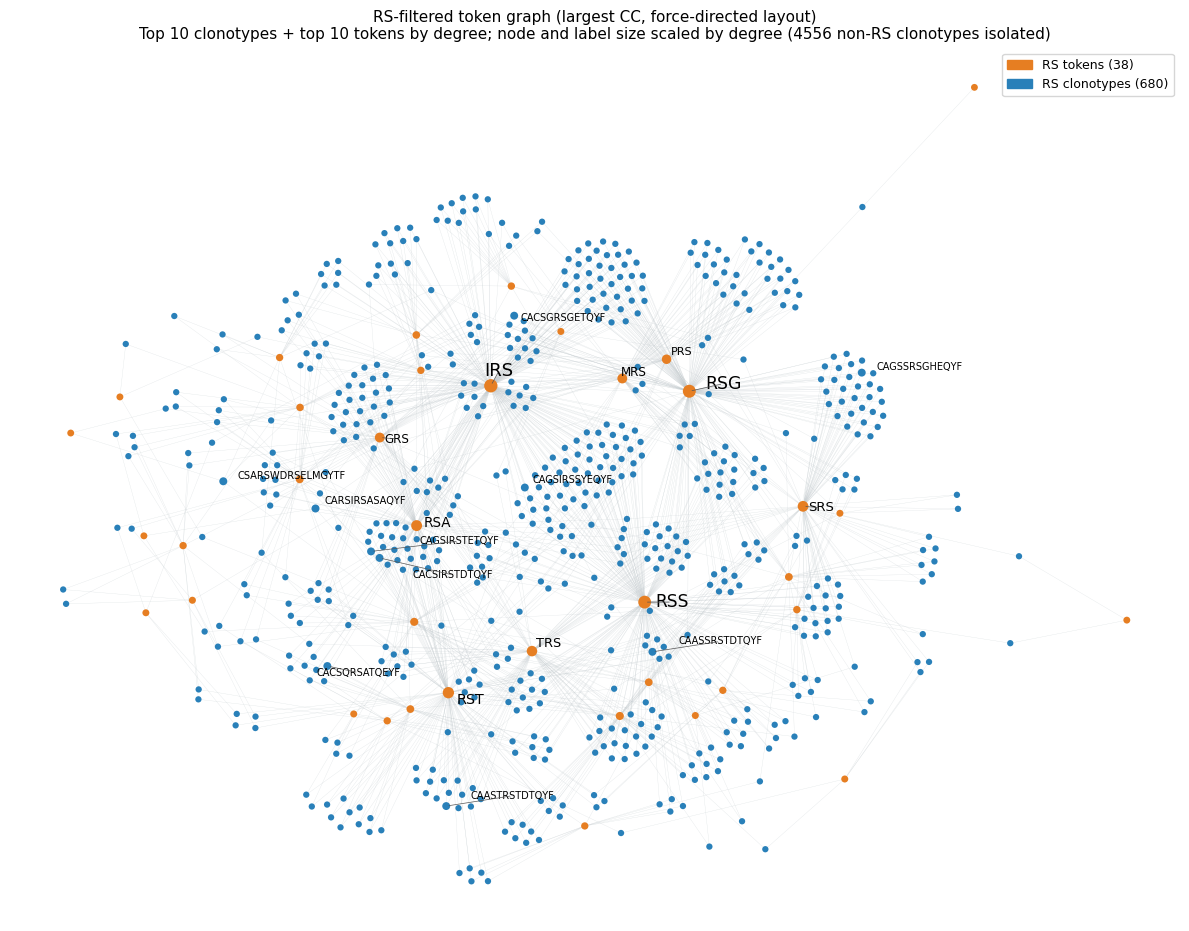

In [17]:
# Visualize the RS-filtered graph with force-directed layout and the same highlight strategy.
subg_rs = filt_cc
degrees_rs = subg_rs.degree()

top_n = 10
clonotype_idx_rs = [v.index for v in subg_rs.vs if v["node_type"] == "rearrangement"]
token_idx_rs = [v.index for v in subg_rs.vs if v["node_type"] == "kmer"]

ordered_clonotypes_rs = sorted(clonotype_idx_rs, key=lambda i: (-degrees_rs[i], subg_rs.vs[i]["name"]))
ordered_tokens_rs = sorted(token_idx_rs, key=lambda i: (-degrees_rs[i], subg_rs.vs[i]["name"]))

top_clonotype_idx_rs = set(ordered_clonotypes_rs[:top_n])
top_token_idx_rs = set(ordered_tokens_rs[:top_n])
highlight_idx_rs = top_clonotype_idx_rs | top_token_idx_rs

layout_rs = subg_rs.layout("fr")
max_deg_rs = max(1, max(degrees_rs))

rs_colors = []
rs_sizes = []
for v in subg_rs.vs:
    is_token = v["node_type"] == "kmer"
    is_top = v.index in highlight_idx_rs
    rs_colors.append("#e67e22" if is_token else "#2980b9")
    base = (24.0 if is_token else 20.0) + 56.0 * (degrees_rs[v.index] / max_deg_rs)
    rs_sizes.append(base + (12.0 if is_top else 0.0))

n_r_cc = sum(1 for v in subg_rs.vs if v["node_type"] == "rearrangement")
n_k_cc = sum(1 for v in subg_rs.vs if v["node_type"] == "kmer")
n_isolated = len(clonotypes) - n_rs_r

coords_rs = layout_rs.coords
x_rs = [coords_rs[i][0] for i in range(subg_rs.vcount())]
y_rs = [coords_rs[i][1] for i in range(subg_rs.vcount())]

fig, ax = plt.subplots(figsize=(12, 12))
for e in subg_rs.es:
    s, t = e.source, e.target
    ax.plot([x_rs[s], x_rs[t]], [y_rs[s], y_rs[t]], color="#bfc7cb", linewidth=0.2, alpha=0.55, zorder=1)

ax.scatter(
    x_rs,
    y_rs,
    s=rs_sizes,
    c=rs_colors,
    edgecolors="none",
    linewidths=0.0,
    zorder=2,
)

texts_rs = []
for idx in sorted(top_clonotype_idx_rs):
    label_size = 7.0 + 6.0 * (degrees_rs[idx] / max_deg_rs)
    texts_rs.append(ax.text(x_rs[idx], y_rs[idx], subg_rs.vs[idx]["name"], fontsize=label_size, color="black", zorder=3))
for idx in sorted(top_token_idx_rs):
    label_size = 7.0 + 6.0 * (degrees_rs[idx] / max_deg_rs)
    texts_rs.append(ax.text(x_rs[idx], y_rs[idx], subg_rs.vs[idx]["name"], fontsize=label_size, color="black", zorder=3))

try:
    from adjustText import adjust_text

    adjust_text(
        texts_rs,
        x=x_rs,
        y=y_rs,
        ax=ax,
        only_move={"points": "xy", "text": "xy"},
        arrowprops=dict(arrowstyle="-", color="#555555", lw=0.5),
        force_text=0.6,
        force_points=0.3,
    )
except Exception:
    pass

legend_handles = [
    mpatches.Patch(color="#e67e22", label=f"RS tokens ({n_k_cc})"),
    mpatches.Patch(color="#2980b9", label=f"RS clonotypes ({n_r_cc})"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
ax.set_title(
    f"RS-filtered token graph (largest CC, force-directed layout)\n"
    f"Top 10 clonotypes + top 10 tokens by degree; node and label size scaled by degree ({n_isolated} non-RS clonotypes isolated)",
    fontsize=11,
)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
plt.tight_layout()
plt.show()